In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
from utils import *
enable_underscore_cleanup() # Sets ipython hook to delete user defined varibles that start with _ at the end of each cell execution

In [2]:
###############################################
runNumbers = [15,16,17,18,19,20,21,22,23,24,25,26,27,28]
### Argon Runs ###
# runNumbers = [93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115]
# folder = '/sdf/data/lcls/ds/cxi/cxil1037623/results/davidjr/'
###
if runNumbers[0]==15:
    folder = '/sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/';
else:
    folder = '/sdf/data/lcls/ds/cxi/cxil1037623/results/davidjr/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = ['jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'dg2ipmReproc/sum',
                   'dg2ipmReproc/peaks',
                   'dg2ipmReproc/xpos',
                   'dg2ipmReproc/ypos',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                   'ipm_dg2/sum',
                   'unixTime',
                   'epicsUser/gasCell_pressure',
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
_data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(_data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(_data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(_data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = _data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = _data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = _data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = _data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(_data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = _data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = _data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = _data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = _data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = _data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = _data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = _data['UserDataCfg/jungfrau4M/y']
z = _data['UserDataCfg/jungfrau4M/z'] 

cmask = _data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = _data['run_indicator'] # run indicator for each shot
#pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = _data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = _data['ebeam/photon_energy']    # x-ray energy energy in eV|
numPhotons = _data['jungfrau4M/Full_thres_sum']
spec = _data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['CXI-DG2-BMMON-WF/ROI_area'] # Downsampling by a factor of 8, makes the refitting much better in the long run
gasPressure = _data['epicsUser/gasCell_pressure']
eventTime = _data['unixTime']
ipm = _data['dg2ipmReproc/sum']
ipmpeaks = _data['dg2ipmReproc/peaks']
xpos = _data['dg2ipmReproc/xpos']
ypos = _data['dg2ipmReproc/ypos']
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0015.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0016.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0017.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0018.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0019.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0020.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0021.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0022.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0023.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch/davidjr/dg2ipmReproc/cxil1037623_Run0024.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/scratch

## Let's take a look at the statistics from the detectors: J4M, DG2-IPM, and XRT SPEC

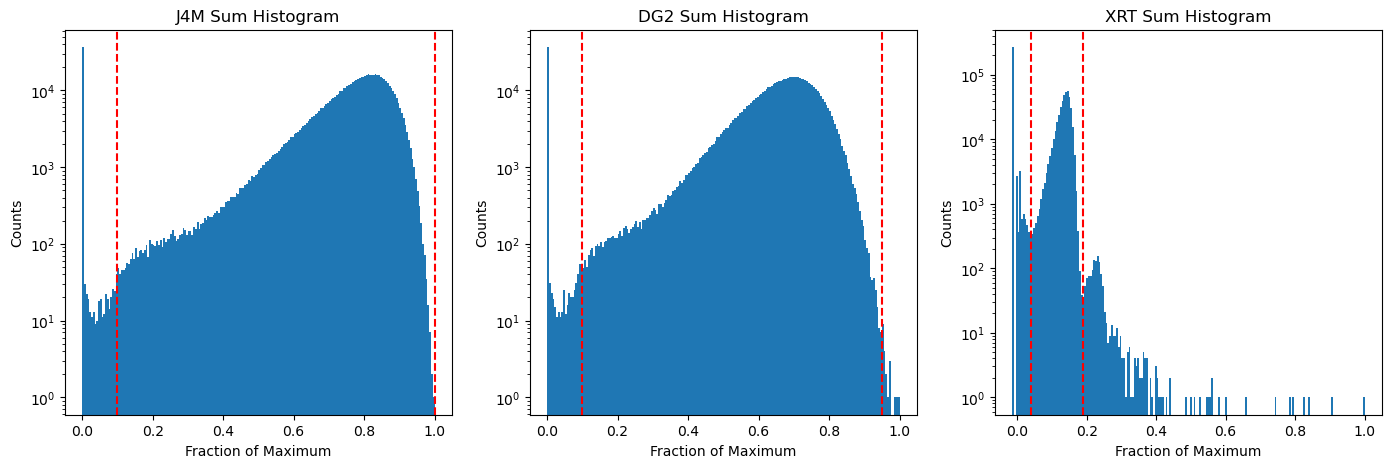

Good data represents 59.82% of the total shots. (419976 out of 702121).


In [3]:
########## Different filter cutoffs
J4M_cutoff = [0.1, 1];
dg2_cutoff = [0.1, 0.95];
spec_cutoff = [0.04, 0.19];
##########

# Precomputing the normalized values
scattered_xrays = np.sum(azav,axis=-1)
scattered_xraysFiltered = np.sum(azavFiltered,axis=-1)
_scattered_xrays_norm = scattered_xrays/scattered_xrays.max();
_ipm_norm = ipm/ipm.max();
_spec_norm = spec.sum(axis=1)/spec.sum(axis=1).max();


plt.figure(figsize=[17,5]) 
plt.subplot(1,3,1)
plt.hist(_scattered_xrays_norm,bins=200);
plt.axvline(J4M_cutoff[0],color='r',linestyle='--')
plt.axvline(J4M_cutoff[1],color='r',linestyle='--')
plt.yscale('log')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')

plt.subplot(1,3,2)
plt.hist(_ipm_norm,bins=200);
plt.axvline(dg2_cutoff[0],color='r',linestyle='--')
plt.axvline(dg2_cutoff[1],color='r',linestyle='--')
plt.yscale('log')
plt.title('DG2 Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')

plt.subplot(1,3,3)
plt.hist(_spec_norm,bins=200);
plt.axvline(spec_cutoff[0],color='r',linestyle='--')
plt.axvline(spec_cutoff[1],color='r',linestyle='--')
plt.yscale('log')
plt.title('XRT Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')

plt.show()
goodIdx = np.logical_and.reduce([
    xrayOn2,
    J4M_cutoff[0] <= _scattered_xrays_norm,
    _scattered_xrays_norm <= J4M_cutoff[1],
    dg2_cutoff[0] <= _ipm_norm,
    _ipm_norm <= dg2_cutoff[1],
    spec_cutoff[0] <= _spec_norm,
    _spec_norm <= spec_cutoff[1],
    ~np.isnan(scattered_xrays)
])

azavFGood = azavFiltered[goodIdx]
azavGood = azav[goodIdx]
specGood = spec[goodIdx]
J4MSumFilter = scattered_xraysFiltered[goodIdx]
J4MSum = scattered_xrays[goodIdx]
gasPGood = gasPressure[goodIdx]
ipmGood = ipm[goodIdx]
# Displaying how much data was kept due to this filtering
_counts,_bins = np.histogram(goodIdx.astype(int),[0,1,2]);
print(f'Good data represents {_counts[1]/np.sum(_counts)*100:.2f}% of the total shots. ({_counts[1]} out of {np.sum(_counts)}).')

## Checking to see if the spectrometer output is offset by one shot or not.

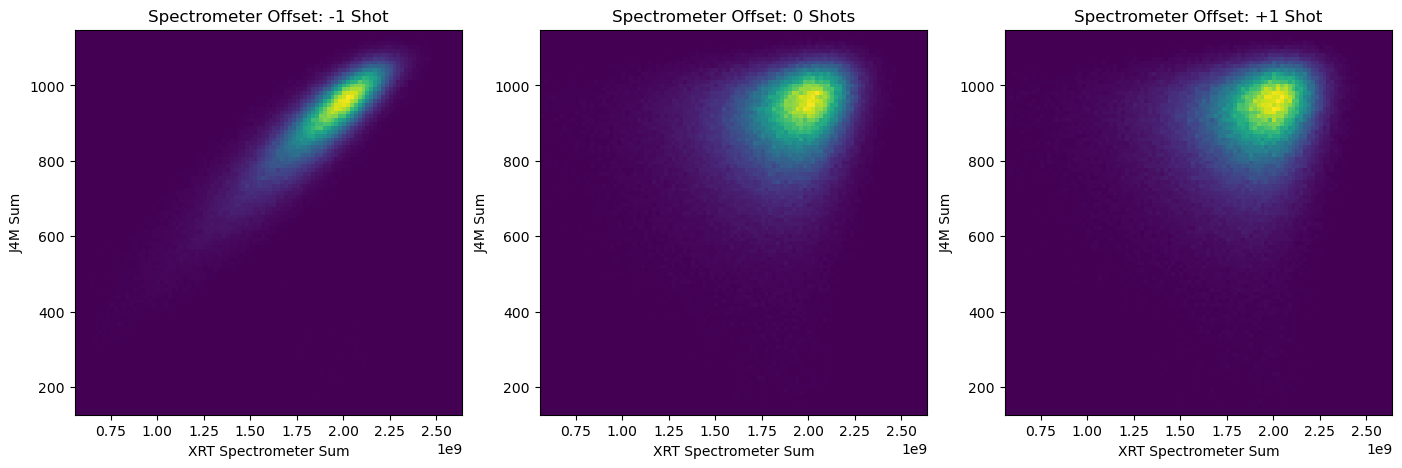

In [4]:
###### Set the offset Here ######
_offset = -1;
#################################
plt.figure(figsize=[17,5]) 
plt.subplot(1,3,1)
plt.hist2d(specGood.sum(axis=1)[0:-2],J4MSum[1:-1],bins=100);
plt.xlabel('XRT Spectrometer Sum')
plt.ylabel('J4M Sum')
plt.title('Spectrometer Offset: -1 Shot')
plt.subplot(1,3,2)
plt.hist2d(specGood.sum(axis=1),J4MSum,bins=100);
plt.xlabel('XRT Spectrometer Sum')
plt.ylabel('J4M Sum')
plt.title('Spectrometer Offset: 0 Shots')
plt.subplot(1,3,3)
plt.hist2d(specGood.sum(axis=1)[1:-1],J4MSum[0:-2],bins=100);
plt.xlabel('XRT Spectrometer Sum')
plt.ylabel('J4M Sum')
plt.title('Spectrometer Offset: +1 Shot')
# Determine slice indices based on offset
if _offset == -1:
    _spec_slice = slice(0, -2)
    _azav_slice = slice(1, -1)
elif _offset == 1:
    _spec_slice = slice(1, -1)
    azav_slice = slice(0, -2)
else:  # offset == 0 or any default
    _spec_slice = azav_slice = slice(None)

# Apply slices
specGood = spec[goodIdx][_spec_slice]
azavGood = azav[goodIdx][_azav_slice]
azavFGood = azavFiltered[goodIdx][_azav_slice]
J4MSum = scattered_xrays[goodIdx][_azav_slice]
J4MSumFilter = scattered_xraysFiltered[goodIdx][_azav_slice]
gasPGood = gasPressure[goodIdx][_azav_slice]
ipmGood = ipm[goodIdx][_azav_slice]
del spec, azav, azavFiltered, scattered_xrays, scattered_xraysFiltered, gasPressure, ipm

## Great, now we have isolated the good data and have fixed any offsets incurred from the XRT Spectromter. Now let's take a look at detector correlations.

### First, let's look at DG2-IPM In some more detail.

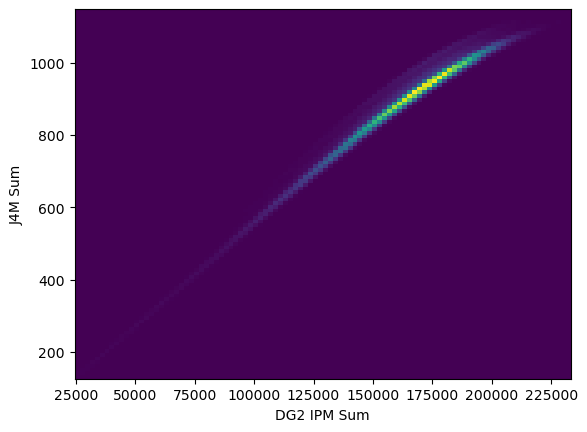

In [5]:
plt.hist2d(ipmGood,J4MSum,bins=100);
plt.xlabel('DG2 IPM Sum');
plt.ylabel('J4M Sum');

### There is something going on here: If we look at the total signal from the J4M divided by the DG2-IPM reading for that shot we can compare it to the gas pressure in the cell.

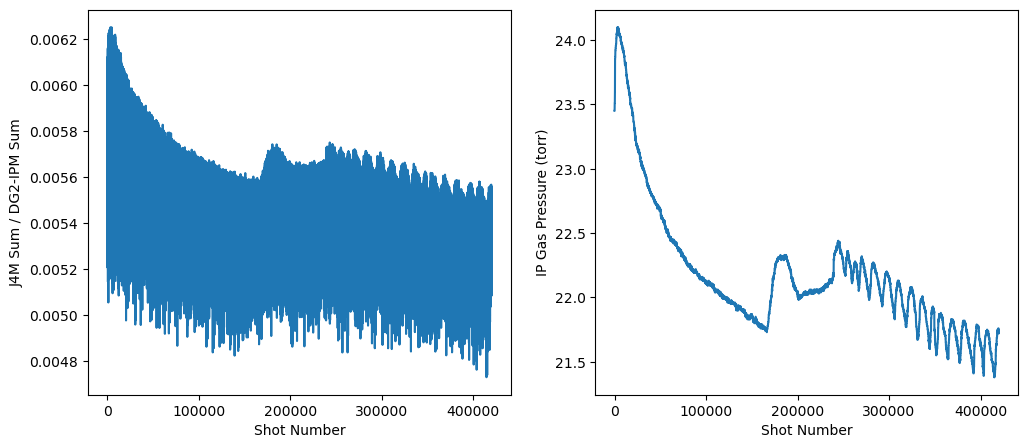

In [6]:
plt.figure(figsize=[12,5]);
# Plotting the I0 normalized J4M Sum
plt.subplot(1,2,1);
plt.plot(J4MSum/ipmGood);
plt.xlabel('Shot Number');
plt.ylabel('J4M Sum / DG2-IPM Sum');
# Plotting the gas pressure
plt.subplot(1,2,2);
plt.plot(gasPGood);
plt.xlabel('Shot Number');
plt.ylabel('IP Gas Pressure (torr)');

### They seem to match. Let's normalize the J4M sum to the gas pressure

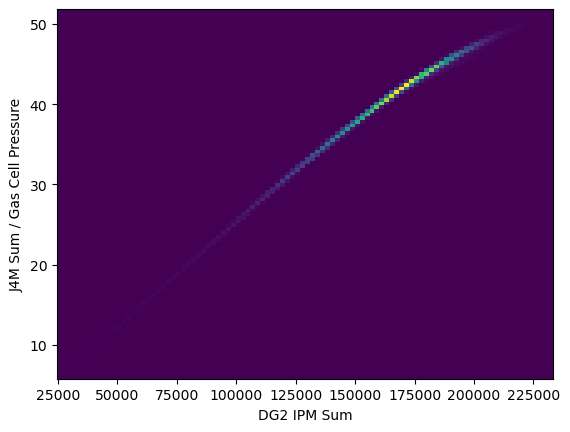

In [7]:
plt.hist2d(ipmGood,J4MSum/gasPGood,bins=100);
plt.xlabel('DG2 IPM Sum');
plt.ylabel('J4M Sum / Gas Cell Pressure');

### Much Better. Let's make some new variables which will store the good data

In [8]:
azavNorm = azavGood/(gasPGood*ipmGood)[:, np.newaxis];
azavFNorm = azavFGood/(gasPGood*ipmGood)[:, np.newaxis];

### Now let's take a look at the spectral data and the J4M Data.

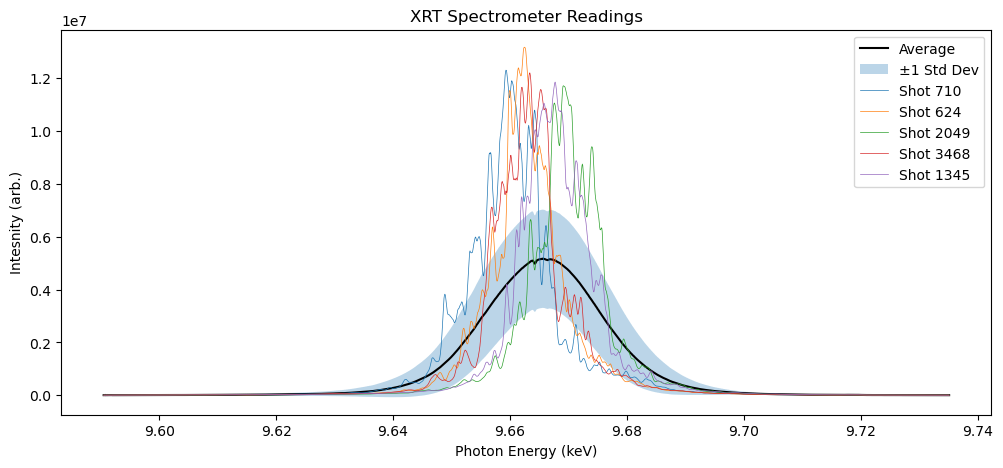

In [10]:
# First, let's laod in the calibrated energy axis.
if runNumbers[0] == 15:
    energyAxis = np.load('ZnCalib/15-28.npy')

# Computing the stdev of each photon energy
_specMean = specGood.mean(axis=0);
_std = specGood.std(axis=0)/2;
plt.figure(figsize=[12,5]);
plt.plot(energyAxis,_specMean,label='Average',color='k');
plt.fill_between(energyAxis, _specMean - _std, _specMean + _std, alpha=0.3, label='±1/2 Std Dev')
for i in range(1,6):
    _shotIdx = np.random.randint(0, 1001)
    plt.plot(energyAxis,specGood[i*_shotIdx],linewidth=0.5,label=f'Shot {i*_shotIdx}');
plt.xlabel('Photon Energy (keV)');
plt.ylabel('Intesnity (arb.)');
plt.title('XRT Spectrometer Readings');
plt.axis('tight')
plt.legend();